In [1]:
!pip install yfinance pandas matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
print("Library siap!")

Library siap!


In [ ]:
stocks = ["AAPL", "GOOGL", "TSLA", "MSFT"]
dfs = {}

for ticker in stocks:
    dfs[ticker] = pd.read_csv(f"../data/processed/{ticker}_indicators.csv")
    dfs[ticker]["Date"] = pd.to_datetime(dfs[ticker]["Date"])

print("Data loaded!")
for ticker in stocks:
    print(f"{ticker}: {len(dfs[ticker])} rows")

Data loaded!
AAPL: 501 rows
GOOGL: 501 rows
TSLA: 501 rows
MSFT: 501 rows


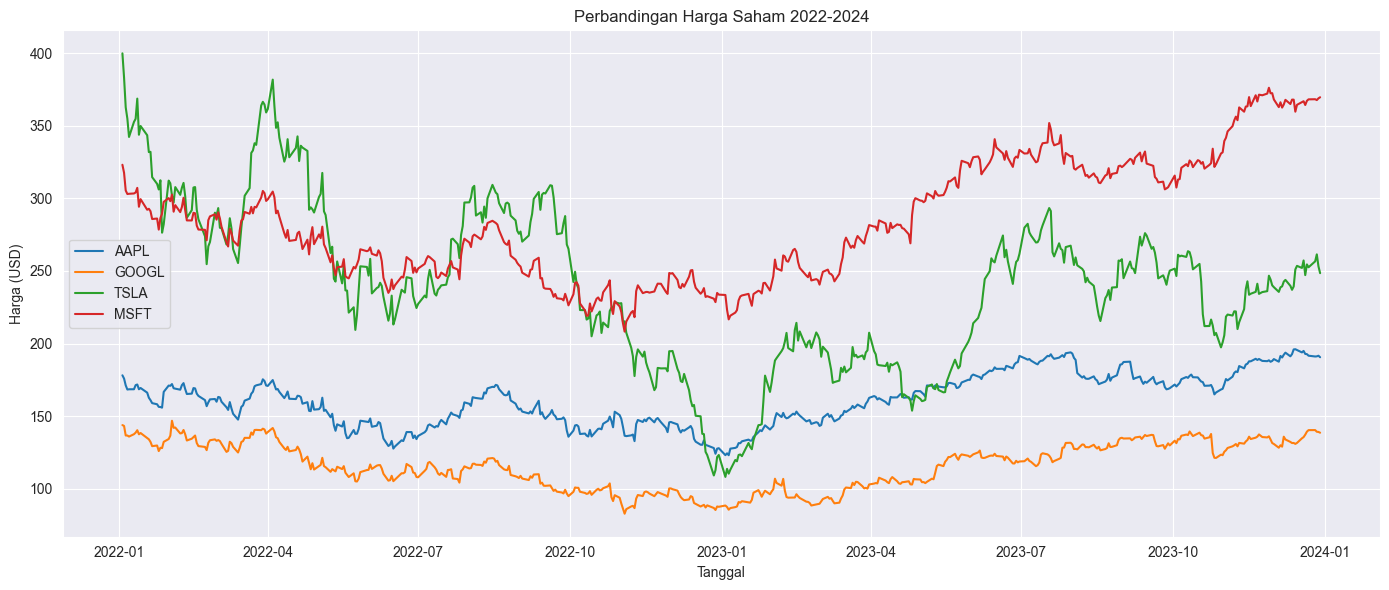

In [ ]:
plt.figure(figsize=(14, 6))

for ticker in stocks:
    plt.plot(dfs[ticker]["Date"], dfs[ticker]["close"], label=ticker)

plt.title("Perbandingan Harga Saham 2022-2024")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/plot_closing_price.png")
plt.show()

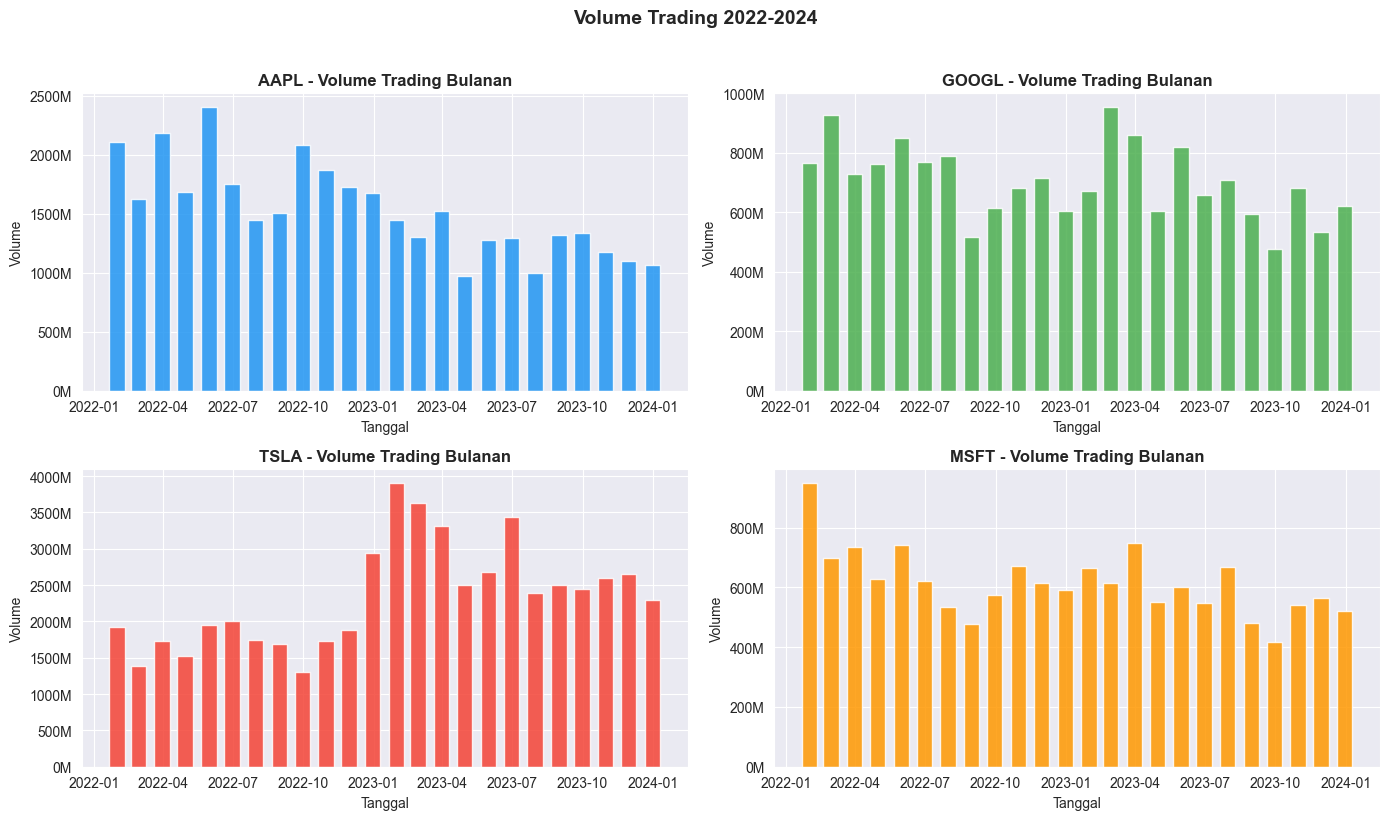

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors = ["#2196F3", "#4CAF50", "#F44336", "#FF9800"]

for i, ticker in enumerate(stocks):
    # Resample ke bulanan biar tidak terlalu rapat
    df_monthly = dfs[ticker].set_index("Date")["Volume"].resample("ME").sum()

    axes[i].bar(df_monthly.index, df_monthly.values,
                color=colors[i], alpha=0.85, width=20)
    axes[i].set_title(f"{ticker} - Volume Trading Bulanan",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Tanggal")
    axes[i].set_ylabel("Volume")
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"{x/1e6:.0f}M"))

plt.suptitle("Volume Trading 2022-2024", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/plot_volume.png", bbox_inches="tight")
plt.show()

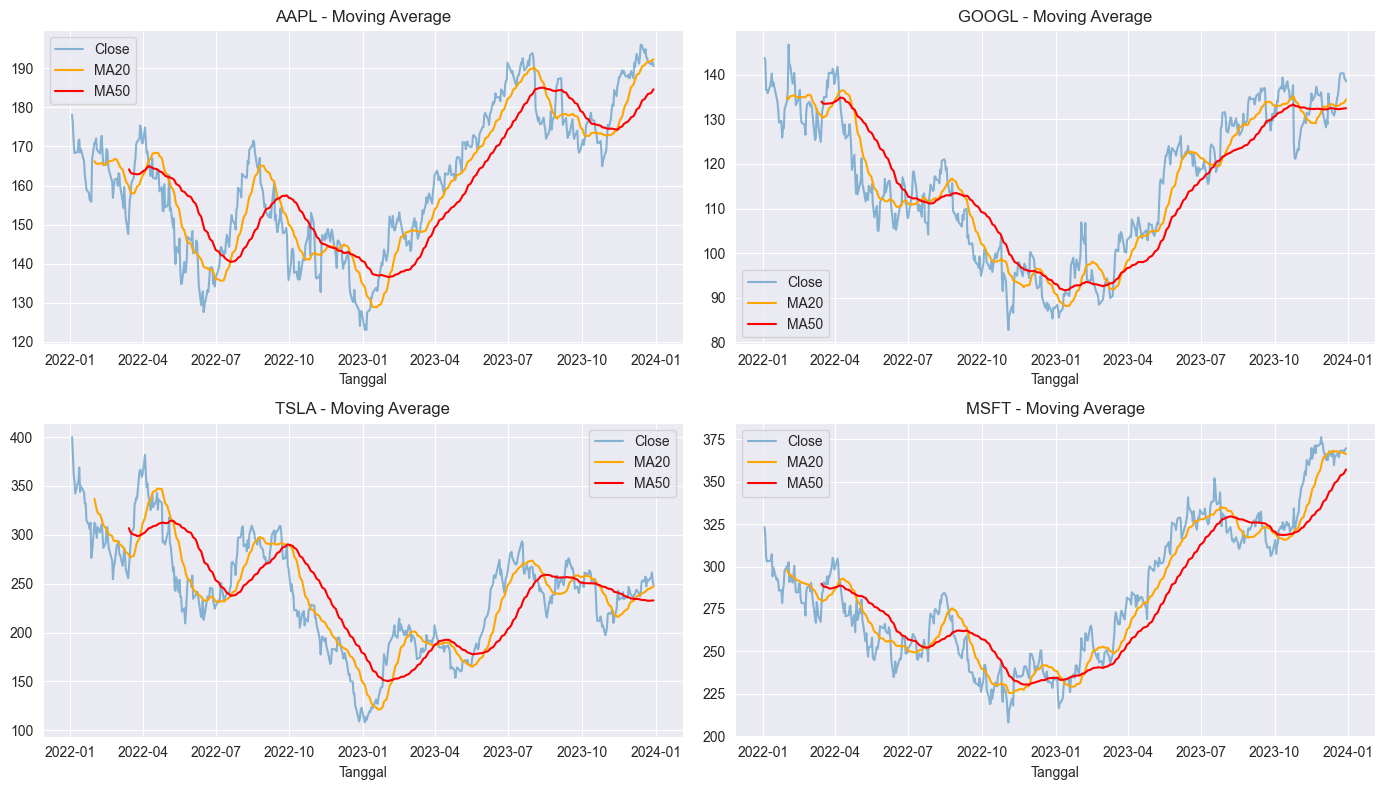

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(stocks):
    axes[i].plot(dfs[ticker]["Date"], dfs[ticker]["close"],
                 label="Close", alpha=0.5)
    axes[i].plot(dfs[ticker]["Date"], dfs[ticker]["MA20"],
                 label="MA20", color="orange")
    axes[i].plot(dfs[ticker]["Date"], dfs[ticker]["MA50"],
                 label="MA50", color="red")
    axes[i].set_title(f"{ticker} - Moving Average")
    axes[i].set_xlabel("Tanggal")
    axes[i].legend()

plt.tight_layout()
plt.savefig("../data/plot_moving_average.png")
plt.show()

In [ ]:
# Cek nama kolom yang ada
print(dfs["AAPL"].columns.tolist())
print(dfs["AAPL"].head(3))

['Date', 'close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50', 'RSI', 'EMA12', 'EMA26', 'MACD', 'Signal']
        Date       close        High         Low        Open     Volume  MA20  \
0 2022-01-03  178.103653  178.954991  173.895953  174.013372  104487900   NaN   
1 2022-01-04  175.843231  179.013699  175.275678  178.710355   99310400   NaN   
2 2022-01-05  171.165802  176.303125  170.891813  175.755146   94537600   NaN   

   MA50  RSI       EMA12       EMA26      MACD    Signal  
0   NaN  NaN  178.103653  178.103653  0.000000  0.000000  
1   NaN  NaN  177.755896  177.936214 -0.180319 -0.036064  
2   NaN  NaN  176.742035  177.434702 -0.692667 -0.167384  
